# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from weakref import WeakKeyDictionary

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.modules.dropout import Dropout
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    b, c, h, w = x.shape
    n = (h * w) // (patch_size**2)
    x = x.unfold(-2, patch_size, patch_size).unfold(-2, patch_size, patch_size)
    x = x.permute(0, 2, 3, 1, 4, 5).reshape((b, n, c*patch_size**2))
    return x

x = torch.randn((32, 3, 224, 224))
print(x[0, :, 0, 0])
x = patchify(x, 16)
print(x[0, 0, 0:3])
print(x[0, 0, 256:259])
print(x[0, 0, 512:515])
x.shape

tensor([-0.7621, -1.4342, -1.0331])
tensor([-0.7621, -0.3767,  0.2760])
tensor([-1.4342, -1.0111,  0.3719])
tensor([-1.0331, -0.7783,  0.1632])


torch.Size([32, 196, 768])

In [3]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.patch_dim = patch_dim
        self.d_model = d_model
        self.weights = nn.Parameter(nn.init.xavier_normal_(torch.zeros((patch_dim, d_model))))
        self.bias = nn.Parameter(torch.zeros((d_model,)))

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        ## in: (b, n, p)
        ## out: (b, n, d)
        return x_patches @ self.weights + self.bias

class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.num_tokens = num_tokens
        self.d_model = d_model
        self.weights = nn.Parameter(nn.init.xavier_normal_(torch.zeros((num_tokens + 1, d_model))))
        self.cls = nn.Parameter(nn.init.xavier_normal_(torch.zeros((1, 1, d_model))))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(f"batch embd shape: {x.shape}")
        ## in: (b, n, d)
        ## out: (b, n+1, d)
        b, _, _ = x.shape
        tensors = [self.cls.expand(b, 1, d_model), x]
        return torch.cat(tensors, dim=1) + self.weights

x = torch.randn((32, 3, 224, 224))
x = patchify(x, 16)
d_model = 64
patch_embd = PatchEmbed(x.size(2), d_model)
embd = patch_embd(x)
pos_embd = PositionalEmbedding(x.size(1), d_model)
embd = pos_embd(embd)
embd.shape

torch.Size([32, 197, 64])

In [4]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        self.glu = nn.GLU()
        self.dropout = nn.Dropout(dropout)
        self.l1 = nn.Linear(d_model, d_ff_gated)
        self.l2 = nn.Linear(d_ff_gated, d_model)
        self.v = nn.Parameter(nn.init.kaiming_normal_(torch.zeros((d_model, d_ff_gated))))
        if variant == "reglu":
            self.activation = nn.ReLU()
        elif variant == "geglu":
            self.activation = nn.GELU()
        elif variant =="swiglu":
            self.activation = lambda x: x * torch.sigmoid(x)
        else:
            self.activation = nn.Sigmoid()


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(f"mlp input shape: {x.shape}")
        # print(f"v shape: {self.v.shape}")
        # print(f"x@v shape: {(x @ self.v).shape}")
        return self.l2(self.activation(self.l1(x)) * (x @ self.v))

In [5]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.wq = nn.Parameter(nn.init.xavier_normal_(torch.zeros((d_model, d_model))))
        self.wk = nn.Parameter(nn.init.xavier_normal_(torch.zeros((d_model, d_model))))
        self.wv = nn.Parameter(nn.init.xavier_normal_(torch.zeros((d_model, d_model))))
        self.ln = nn.LayerNorm(d_model)
        self.mha = nn.MultiheadAttention(d_model, n_heads)
        self.dropout = nn.Dropout(dropout)
        self.block2 = nn.Sequential(
            nn.LayerNorm(d_model),
            mlp,
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(f"x shape: {x.shape}")
        ln_x = self.ln(x)
        q = ln_x @ self.wq
        k = ln_x @ self.wk
        v = ln_x @ self.wv
        # print(f"q shape: {q.shape}")
        attn_output, _ = self.mha(q, k, v)
        # print(f"attn shape: {attn_output.shape}")
        x = x + self.dropout(attn_output)
        # print(f"block1 shape: {x.shape}")
        return x + self.block2(x)

In [6]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        # print(f"grid: {grid}")
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # TODO: implement a strategy for embedding the patches
        self.embed = nn.Sequential(
            PatchEmbed(patch_dim, d_model),
            PositionalEmbedding(self.num_tokens, d_model)
        )

        # TODO: implement a strategy to select the right mlp version for your experiment

        d_ff_gated = (d_ff * 2) // 3
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=FeedForward(d_model, d_ff, dropout) if mlp_kind=="baseline" else GLUFeedForward(d_model, d_ff_gated, dropout, mlp_kind),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        # self.head = FeedForward(patch_dim, 10, dropout)
        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(x.shape)
        x = self.embed(patchify(x, self.patch_size))
        # print(x.shape)
        for block in self.blocks:
            # print(f"block x shape: {x.shape}")
            x = block(x)
        # print(f"x shape: {x.shape}")
        mean_pool = x.mean(dim=1)
        # print(f"mean shape: {mean_pool.shape}")
        logits = self.head(mean_pool)
        # print(f"logits shape: {logits.shape}")
        return logits

In [7]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            # print(f"output shape: {logits.shape}")
            # print(f"target shape: {yb.shape}")
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        'train_losses': train_losses,
        'test_accuracy': test_accs,
    }

In [9]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["baseline", "sigmoid", "reglu", "geglu", "swiglu"] # TODO: Name your runs
results = []

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    print(sum(p.numel() for p in model.parameters()))
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)

129546

Run: baseline | 
[baseline] epoch 1/5 | test acc: 0.6448
[baseline] epoch 2/5 | test acc: 0.8223
[baseline] epoch 3/5 | test acc: 0.8543
[baseline] epoch 4/5 | test acc: 0.8859
[baseline] epoch 5/5 | test acc: 0.9001
129118

Run: sigmoid | 
[sigmoid] epoch 1/5 | test acc: 0.7627
[sigmoid] epoch 2/5 | test acc: 0.8625
[sigmoid] epoch 3/5 | test acc: 0.8923
[sigmoid] epoch 4/5 | test acc: 0.9049
[sigmoid] epoch 5/5 | test acc: 0.9135
129118

Run: reglu | 
[reglu] epoch 1/5 | test acc: 0.8849
[reglu] epoch 2/5 | test acc: 0.9321
[reglu] epoch 3/5 | test acc: 0.9499
[reglu] epoch 4/5 | test acc: 0.9567
[reglu] epoch 5/5 | test acc: 0.9614
129118

Run: geglu | 
[geglu] epoch 1/5 | test acc: 0.8948
[geglu] epoch 2/5 | test acc: 0.9310
[geglu] epoch 3/5 | test acc: 0.9537
[geglu] epoch 4/5 | test acc: 0.9583
[geglu] epoch 5/5 | test acc: 0.9615
129118

Run: swiglu | 
[swiglu] epoch 1/5 | test acc: 0.8568
[swiglu] epoch 2/5 | test acc: 0.9193
[swiglu] epoch 3/5 | test acc: 0.9385
[swig

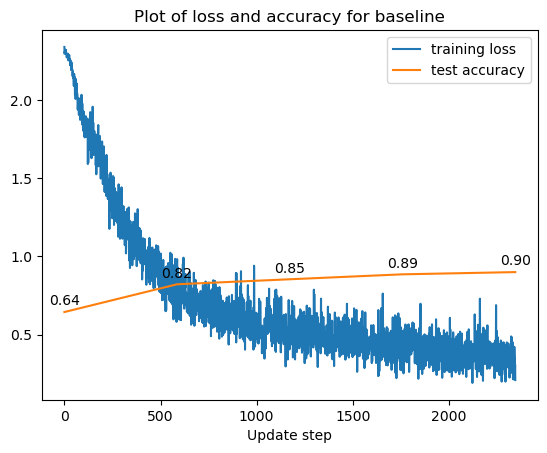

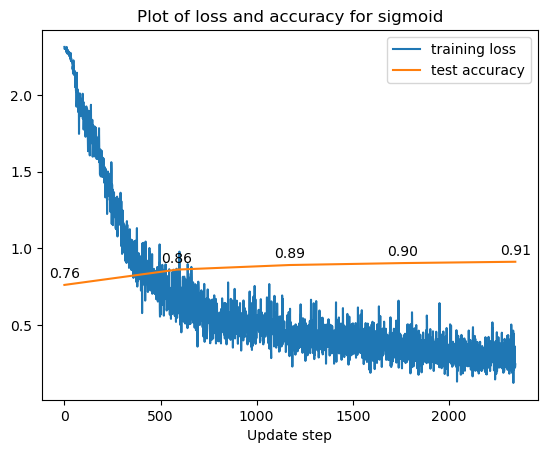

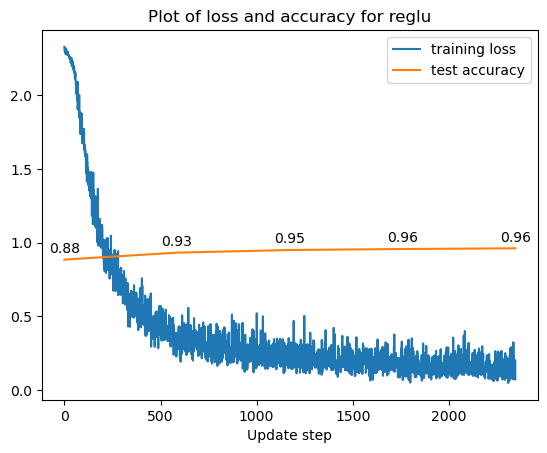

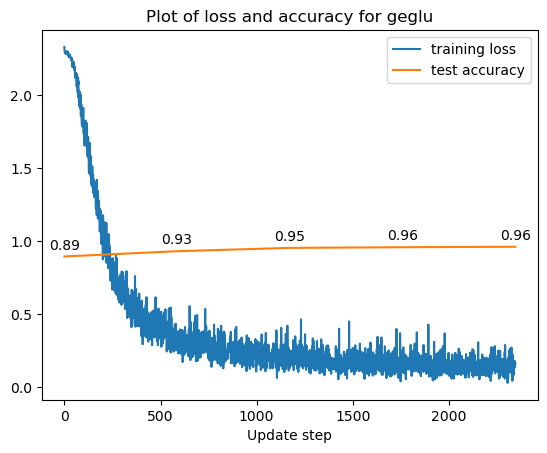

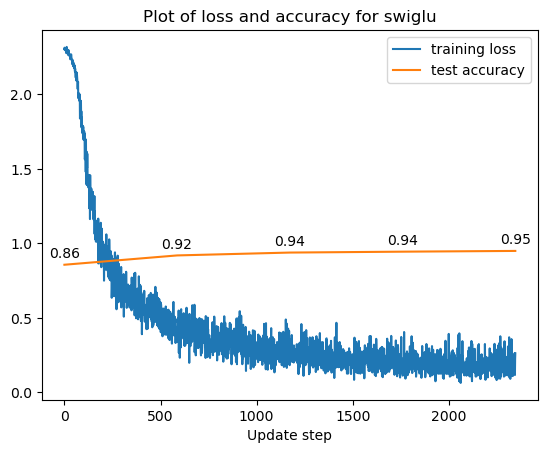

In [16]:
import matplotlib.pyplot as plt
import numpy as np

for kind, result in zip(runs, results):
    losses = result['train_losses']
    num_steps = len(losses)
    x_acc, y_acc = np.linspace(0, num_steps, 5), result['test_accuracy']
    plt.plot(np.linspace(0, num_steps, num_steps), losses, label="training loss")
    plt.plot(x_acc, y_acc, label="test accuracy")
    for x, y in zip(x_acc, y_acc):
        plt.annotate(f"{y:.2f}",
                     (x, y),
                     textcoords="offset points",
                     xytext=(0, 5),   # shift text slightly upward
                     ha='center')
    plt.title(f'Plot of loss and accuracy for {kind}')
    plt.legend()
    plt.xlabel('Update step')
    plt.show()
    